This code processes CSV file output from Raven Expedition from multiple sites, cleans and standardizes the data, extracts temporal metadata, and combines all site data into a single Parquet file. It then filters and downsamples the data to hourly resolution, restricts frequencies to ≤2000 Hz, and generates multi-panel LTSA (Long-Term Spectral Average) heatmaps per site for visualization. Start in the second code block once the parquet file has been created by the first code block to avoid having to reprocess the csv's.

In [3]:
import os
import pandas as pd
import numpy as np

data_root = r"/Volumes/SeaBABELa/Expedition_LTSAs"
output_dir = r"/Volumes/SeaBABELa/Expedition_LTSAs"
parquet_dir = os.path.join(output_dir, "parquet_files")
ltsa_dir = os.path.join(output_dir, "ltsa_results")

# Create output directories
os.makedirs(output_dir, exist_ok=True)
os.makedirs(parquet_dir, exist_ok=True)
os.makedirs(ltsa_dir, exist_ok=True)

site_dfs = {}
bad_files = []

print("Processing CSV files...")

for root, _, files in os.walk(data_root):
    for file in files:
        if file.endswith(".csv"):
            filepath = os.path.join(root, file)
            site_name = os.path.basename(root)

            try:
                # Extract date from filename (e.g., 20250621_202547_20240115.csv → 20240115)
                parts = file.split("_")
                if len(parts) < 3 or not parts[2].endswith(".csv"):
                    print(f"Skipping {file} due to unexpected filename format.")
                    bad_files.append(filepath)
                    continue
                date_str = parts[2].replace(".csv", "")

                # Read CSV
                df = pd.read_csv(filepath)

                # Rename first column to 'datetime'
                df.rename(columns={df.columns[0]: 'datetime'}, inplace=True)

                if df.shape[1] < 2:
                    print(f"Skipping {filepath} due to missing columns.")
                    bad_files.append(filepath)
                    continue

                # Convert datetime
                df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
                if df['datetime'].isna().any():
                    print(f"Skipping {filepath} due to invalid datetime format.")
                    bad_files.append(filepath)
                    continue

                # Convert numeric columns and replace inf
                df.iloc[:, 1:] = df.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')
                df.iloc[:, 1:] = df.iloc[:, 1:].replace([np.inf, -np.inf], np.nan)

                # Add metadata columns
                new_cols = pd.DataFrame({
                    'hour': df['datetime'].dt.hour,
                    'date': df['datetime'].dt.date,
                    'day_of_year': df['datetime'].dt.dayofyear,
                    'month': df['datetime'].dt.month,
                    'site': site_name,
                    'file_date': pd.to_datetime(date_str, format="%Y%m%d", errors='coerce')
                }, index=df.index)

                df = pd.concat([df, new_cols], axis=1)

                if site_name not in site_dfs:
                    site_dfs[site_name] = []
                site_dfs[site_name].append(df)

                print(f"Processed: {file} from {site_name}")

            except Exception as e:
                print(f"Error processing {filepath}: {e}")
                bad_files.append(filepath)

print(f"\nProcessing complete. Found {len(site_dfs)} sites.")
print(f"Bad files: {len(bad_files)}")

# Combine all site data
print("\nCombining all sites into master dataset...")
all_site_data = []
for site_name, df_list in site_dfs.items():
    try:
        combined_df = pd.concat(df_list, ignore_index=True)
        all_site_data.append(combined_df)
        print(f"  - {site_name}: {len(combined_df):,} rows")
    except Exception as e:
        print(f"  Error combining {site_name}: {e}")
        for df in df_list:
            all_site_data.append(df)

# Final master DataFrame
if all_site_data:
    master_df = pd.concat(all_site_data, ignore_index=True)
    print(f"\nFinal dataset: {len(master_df):,} rows, {len(master_df.columns)} columns")

    # Export to Parquet
    master_parquet_path = os.path.join(parquet_dir, "all_sites_combined.parquet")
    master_df.to_parquet(master_parquet_path, index=False)
    print(f"Saved Parquet: {master_parquet_path}")

    # Export to CSV (optional, if file is not too large)
    master_csv_path = os.path.join(output_dir, "all_sites_combined.csv")
    master_df.to_csv(master_csv_path, index=False)
    print(f"Saved CSV: {master_csv_path}")

    print(f"Sites included: {sorted(master_df['site'].unique().tolist())}")
else:
    print("No valid data found to export.")

Processing CSV files...
Processed: 20250621_203511_20240116.csv from BVI_mangroves_6880_HansA
Skipping ._20250621_203511_20240116.csv due to unexpected filename format.
Processed: 20250621_203511_20240117.csv from BVI_mangroves_6880_HansA
Skipping ._20250621_203511_20240117.csv due to unexpected filename format.
Processed: 20250621_203511_20240118.csv from BVI_mangroves_6880_HansA
Skipping ._20250621_203511_20240118.csv due to unexpected filename format.
Processed: 20250621_203511_20240119.csv from BVI_mangroves_6880_HansA
Skipping ._20250621_203511_20240119.csv due to unexpected filename format.
Processed: 20250621_203511_20240120.csv from BVI_mangroves_6880_HansA
Skipping ._20250621_203511_20240120.csv due to unexpected filename format.
Processed: 20250621_203511_20240121.csv from BVI_mangroves_6880_HansA
Skipping ._20250621_203511_20240121.csv due to unexpected filename format.
Processed: 20250621_203511_20240122.csv from BVI_mangroves_6880_HansA
Skipping ._20250621_203511_20240122.

If a parquet file already exists, start here

In [11]:
def plot_ltsa_1_3_octave_per_site(data_dict, groupby_col, freq_cols_for_plot, main_title, viz_dir,
                                  save_filename, figsize_per_subplot=(10, 4), subtitle=None, save_plot=True):
    """
    Generates and plots 1/3 octave band Long Term Spectral Averages (LTSA) per site,
    with shared y-axis and a single color bar.
    """
    df_plot_data = data_dict['Hourly']
    sites = sorted(df_plot_data['site'].unique())
    nrows = len(sites)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=1,
        figsize=(figsize_per_subplot[0], figsize_per_subplot[1] * nrows),
        sharex=False,
        sharey=True
    )
    fig.subplots_adjust(hspace=0.6)

    if nrows == 1:
        axes = [axes]

    vmin, vmax = None, None
    heatmap_data = []

    # Precompute heatmap data and min/max
    for site in sites:
        df_site = df_plot_data[df_plot_data['site'] == site].copy()
        df_site.set_index(groupby_col, inplace=True)
        data = df_site[freq_cols_for_plot].sort_index()
        heatmap_data.append(data)

        if not data.empty:
            current_min, current_max = data.min().min(), data.max().max()
            vmin = current_min if vmin is None else min(vmin, current_min)
            vmax = current_max if vmax is None else max(vmax, current_max)

    # Plot each site
    for i, (site, data) in enumerate(zip(sites, heatmap_data)):
        ax = axes[i]
        if data.empty:
            ax.set_visible(False)
            continue

        sns.heatmap(
            data.T,
            ax=ax,
            cmap='magma',
            cbar=False,
            xticklabels=False,
            yticklabels=True,
            vmin=vmin,
            vmax=vmax
        )

        # X-axis ticks
        valid_indices = data.index[data.index.notnull()]
        if not valid_indices.empty:
            num_ticks = min(8, len(valid_indices))
            tick_positions = np.linspace(0, len(data) - 1, num_ticks).astype(int)
            tick_labels = [data.index[i].strftime('%Y-%m-%d') for i in tick_positions if i < len(data)]
            ax.set_xticks(tick_positions)
            ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=7)
            ax.set_xlabel("")  # Suppress automatic x-axis label
        else:
            ax.set_xticks([])

        # Y-axis ticks: rounded center freqs only
        freq_labels = [int(col.replace("Hz", "")) for col in data.columns if "Hz" in col]
        desired_freqs = [100, 200, 400, 800, 1600]
        tick_indices = [i + 0.5 for i, f in enumerate(freq_labels) if f in desired_freqs]
        tick_labels = [f"{f}Hz" for f in freq_labels if f in desired_freqs]

        ax.set_yticks(tick_indices)
        ax.set_yticklabels(tick_labels)
        ax.invert_yaxis()

        pretty_site = site_labels.get(site, site)
        ax.set_title(f"{pretty_site}", fontsize=10)
        ax.set_ylabel("Center Frequency (Hz)")

    # Shared colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    sm = plt.cm.ScalarMappable(cmap='magma', norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, label='Mean SPL (dB re 1 µPa)')

    # Titles
    fig.suptitle(main_title, fontsize=14, y=1.02)
    if subtitle:
        fig.text(0.5, 0.985, subtitle, ha='center', fontsize=10)

    plt.tight_layout(rect=[0, 0, 0.9, 0.96])

    if save_plot:
        os.makedirs(viz_dir, exist_ok=True)
        save_path = os.path.join(viz_dir, save_filename)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_path}")

    plt.show()
    plt.close(fig)

/var/folders/jz/brmpr50d5w16zvg_m29fgzfc0000gn/T/ipykernel_1017/377774633.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.96])


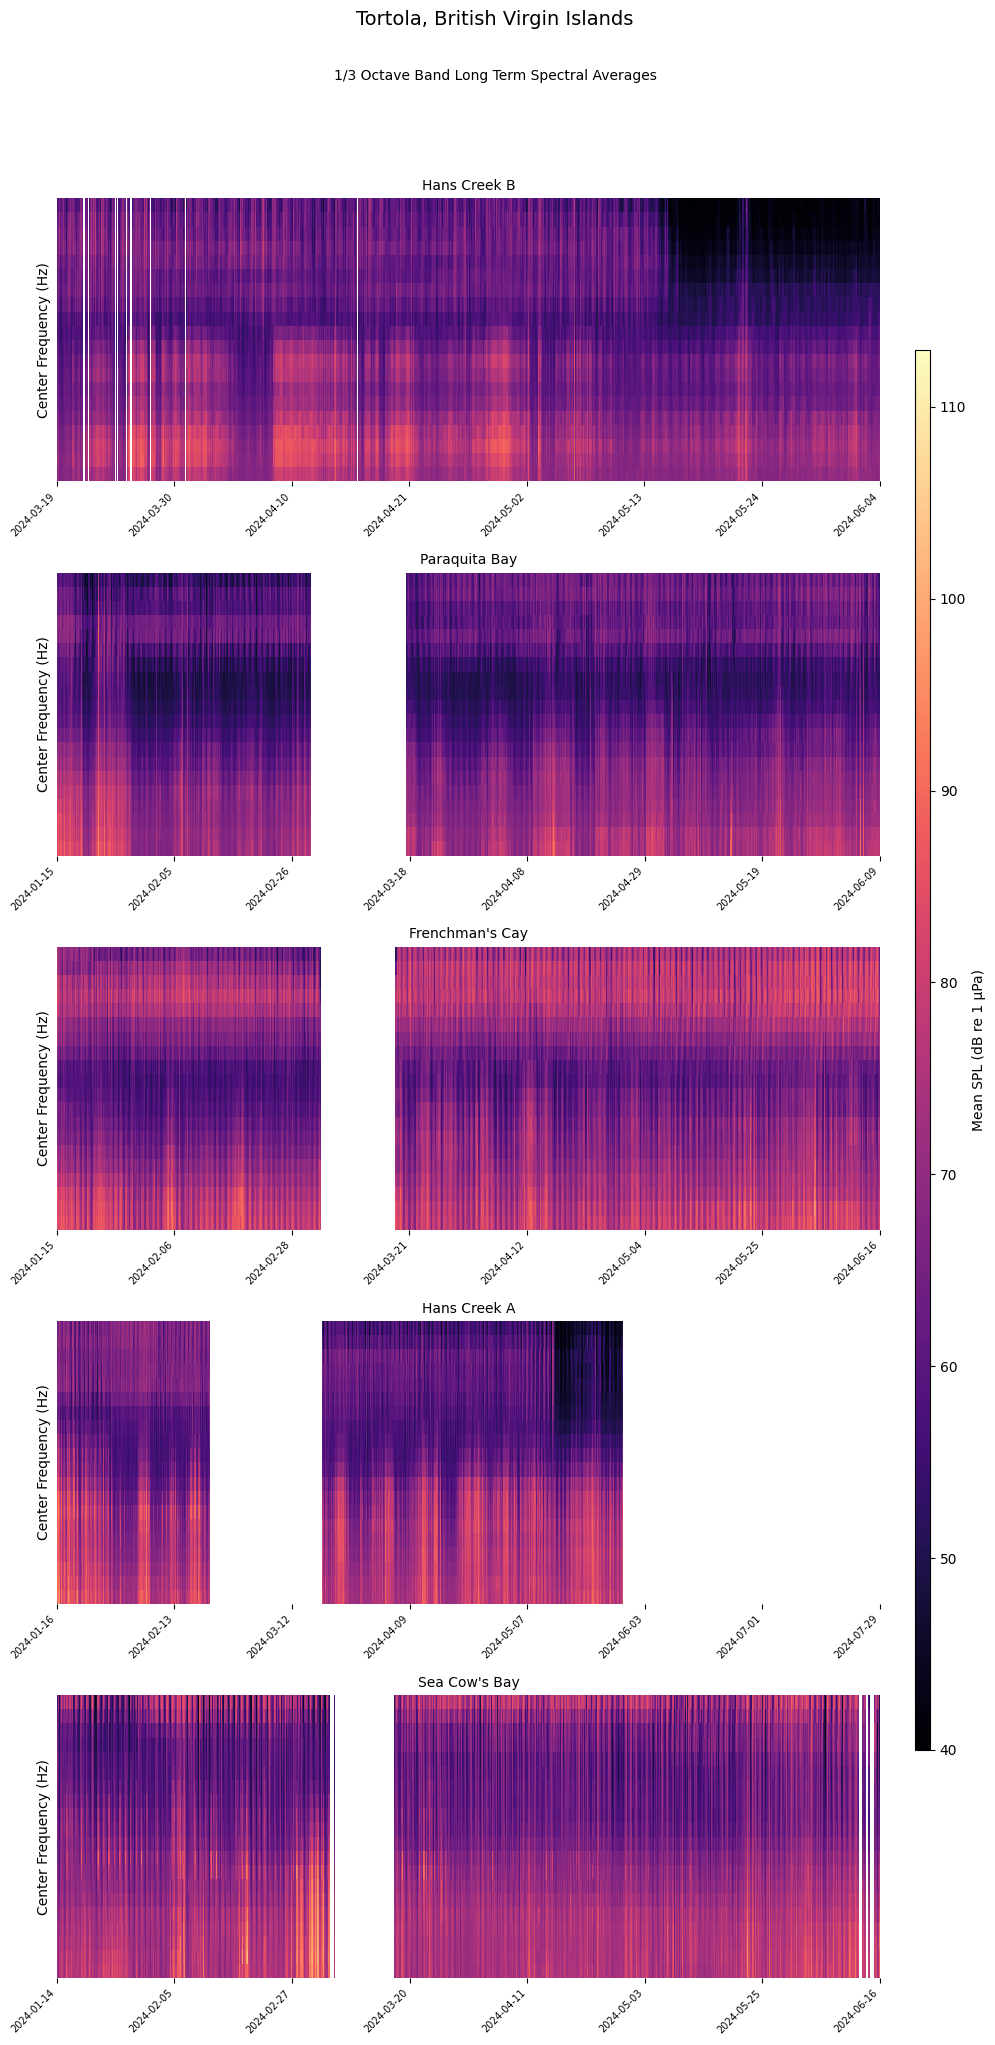

In [12]:
plot_ltsa_1_3_octave_per_site(
    data_dict=data_dict_for_plot,
    groupby_col='datetime',
    freq_cols_for_plot=freq_cols_for_plot,
    main_title='Tortola, British Virgin Islands',
    subtitle='1/3 Octave Band Long Term Spectral Averages',
    viz_dir=viz_dir,
    save_filename='bvi_ltsa.png',
    save_plot=False
)
